# Debug: Benchmark vs Notebook Training

This notebook replicates the **exact** training flow of `run_tonic_benchmark.py --method grad_guarino --perturbation 0.05`
step by step, so we can compare each stage with the working `training_synthetic_singlestage` notebook.

## Strategy
1. Run the benchmark path (step current, `setup_trainable_cell_step`, `data_stimuli=None`)
2. Run the notebook path (data stimulate, `setup_trainable_cell`, `data_stimuli=tuple`)
3. Compare at each stage: stimulus, target voltage, features, loss, gradients

In [14]:
import logging
logging.basicConfig(level=logging.INFO)

import jax
import jax.numpy as jnp
import jaxley as jx
import numpy as np
import matplotlib.pyplot as plt

from ADoptEX.core.parameters import PARAM_BOUNDS, DEFAULT_PARAMS
from ADoptEX.core.simulation import simulate_jaxley, create_adex_cell
from ADoptEX.loss.guarino import (
    extract_experimental_features,
    make_guarino_loss_fn,
    GuarinoLossConfig,
    GuarinoFeatureExtractor,
)
from ADoptEX.training.trainer import (
    TrainingConfig,
    setup_trainable_cell,
    setup_trainable_cell_step,
    train,
)
from ADoptEX.benchmark.sampling import TONIC_GROUND_TRUTHS
from ADoptEX.benchmark.scenarios import SyntheticScenario, MEMBRANE_PARAMS
from ADoptEX.benchmark.runner import prepare_target_data, generate_initial_params

## 1. Pick a single scenario (GT 0, 5% perturbation)

In [15]:
gt = TONIC_GROUND_TRUTHS[0]
ground_truth_params = gt["params"].copy()
stim_current_pA = gt["stim_current_pA"]

print("Ground truth params:")
for k, v in sorted(ground_truth_params.items()):
    print(f"  {k:>15s} = {v}")
print(f"  stim_current_pA = {stim_current_pA}")

Ground truth params:
              C_m = 200.0
              E_L = -90.0
                a = 2.0
                b = 0.0
          delta_T = 4.0
              g_L = 10.0
            tau_w = 30.0
              v_T = -55.5
          v_reset = -70.0
      v_threshold = 0.0
  stim_current_pA = 773.0


In [16]:
# Scenario exactly as the benchmark creates it
scenario = SyntheticScenario(
    name="debug_gt00_05pct",
    ground_truth_params=ground_truth_params,
    trainable_params=list(MEMBRANE_PARAMS),
    stim_current_pA=stim_current_pA,
    perturbation=0.05,
    n_starts=10,
    seed=42,
)

print(f"dt_ms = {scenario.dt_ms}")
print(f"t_max_ms = {scenario.t_max_ms}")
print(f"stim_delay = {scenario.stim_delay_ms}, stim_duration = {scenario.stim_duration_ms}")
print(f"trainable: {scenario.trainable_params}")

dt_ms = 0.1
t_max_ms = 500.0
stim_delay = 50.0, stim_duration = 400.0
trainable: ['C_m', 'g_L', 'E_L', 'v_T', 'delta_T', 'v_reset']


## 2. Generate target data (ground truth simulation)

/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Target voltage shape: (5001,)
Target spike times: [ 67.2  78.6  90.3 102.2 114.2 126.3 138.5 150.8 163.1 175.4 187.7 200.
 212.3 224.6 236.9 249.2 261.5 273.8 286.1 298.4 310.7 323.  335.3 347.6
 359.9 372.2 384.5 396.8 409.1 421.4 433.7 446. ]
N spikes: 32
stim_end_index: 4500
dt_ms: 0.1
duration_ms: 500.0


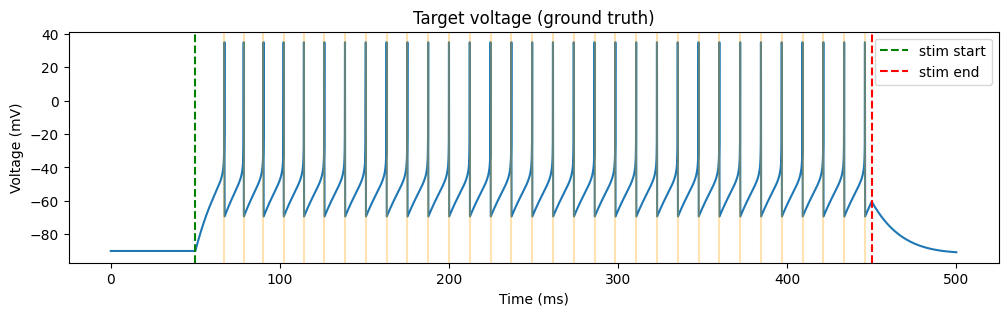

In [17]:
target_data = prepare_target_data(scenario)

print(f"Target voltage shape: {target_data['voltage'].shape}")
print(f"Target spike times: {target_data['spike_times']}")
print(f"N spikes: {len(target_data['spike_times'])}")
print(f"stim_end_index: {target_data['stim_end_index']}")
print(f"dt_ms: {target_data['dt_ms']}")
print(f"duration_ms: {target_data['duration_ms']}")

plt.figure(figsize=(12, 3))
t = np.arange(len(target_data['voltage'])) * target_data['dt_ms']
plt.plot(t, target_data['voltage'])
plt.axvline(scenario.stim_delay_ms, color='g', ls='--', label='stim start')
plt.axvline(scenario.stim_delay_ms + scenario.stim_duration_ms, color='r', ls='--', label='stim end')
for st in target_data['spike_times']:
    plt.axvline(st, color='orange', alpha=0.3)
plt.title('Target voltage (ground truth)')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

## 3. Generate initial params (benchmark LHS method)

In [18]:
start_index = 0
initial_params = generate_initial_params(scenario, start_index)

print("Initial params (benchmark LHS, 5% perturbation):")
for k in sorted(ground_truth_params.keys()):
    gt_val = ground_truth_params[k]
    init_val = initial_params[k]
    pct = abs(init_val - gt_val) / abs(gt_val) * 100 if gt_val != 0 else 0
    trainable = "*" if k in scenario.trainable_params else " "
    print(f"  {trainable} {k:>15s}: GT={gt_val:>10.3f}  init={init_val:>10.3f}  err={pct:.2f}%")

Initial params (benchmark LHS, 5% perturbation):
  *             C_m: GT=   200.000  init=   191.665  err=4.17%
  *             E_L: GT=   -90.000  init=   -86.611  err=3.77%
                  a: GT=     2.000  init=     2.000  err=0.00%
                  b: GT=     0.000  init=     0.000  err=0.00%
  *         delta_T: GT=     4.000  init=     3.818  err=4.55%
  *             g_L: GT=    10.000  init=     9.589  err=4.11%
              tau_w: GT=    30.000  init=    30.000  err=0.00%
  *             v_T: GT=   -55.500  init=   -56.558  err=1.91%
  *         v_reset: GT=   -70.000  init=   -72.274  err=3.25%
        v_threshold: GT=     0.000  init=     0.000  err=0.00%


## 4. Benchmark training config (exact match)

In [19]:
# This is EXACTLY what get_tonic_methods() returns for grad_guarino
config_benchmark = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.01,
    n_epochs=50,
    print_every=1,  # print every epoch for debugging
    surrogate_type="sigmoid",
    surrogate_slope=2.0,
    use_param_transform=True,
    clip_to_bounds=False,
    return_best=True,
    verbose=True,
)

print("Benchmark config:")
for k, v in vars(config_benchmark).items():
    print(f"  {k}: {v}")

Benchmark config:
  optimizer: polyak
  learning_rate: 0.01
  n_epochs: 50
  grad_clip_norm: None
  polyak_alpha: 1.0
  polyak_beta: 1.0
  lr_schedule: None
  lr_decay_rate: 0.01
  surrogate_type: sigmoid
  surrogate_slope: 2.0
  clip_to_bounds: False
  use_param_transform: True
  print_every: 1
  verbose: True
  trainable_params: None
  return_best: True


## 5A. BENCHMARK PATH: setup_trainable_cell_step + data_stimuli=None

In [20]:
# This is exactly what run_gradient() does in runner.py
cell_bench, _, t_max_bench, trainable_params_bench = setup_trainable_cell_step(
    initial_params=initial_params,
    stim_current_pA=scenario.stim_current_pA,
    stim_duration_ms=scenario.stim_duration_ms,
    stim_delay_ms=scenario.stim_delay_ms,
    dt_ms=scenario.dt_ms,
    config=config_benchmark,
    trainable_params=scenario.trainable_params,
)

print(f"t_max_bench = {t_max_bench}")
print(f"trainable_params_bench = {trainable_params_bench}")
print(f"data_stimuli = None (stimulus baked into cell via cell.stimulate)")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Added 1 external_states. See `.externals` for details.
t_max_bench = 500.0
trainable_params_bench = [{'capacitance': Array([191.66512], dtype=float32)}, {'AdEx_g_L': Array([9.589013], dtype=float32)}, {'AdEx_E_L': Array([-86.610664], dtype=float32)}, {'AdEx_v_T': Array([-56.55828], dtype=float32)}, {'AdEx_delta_T': Array([3

In [21]:
# Build loss function exactly as _build_loss_fn does for guarino
dt_ms = target_data["dt_ms"]
stim_end_index = target_data["stim_end_index"]
stim_duration_ms = target_data["stim_duration_ms"]

exp_features_bench = extract_experimental_features(
    voltage_trace=jnp.array(target_data["voltage"]),
    dt_ms=dt_ms,
    stim_duration_ms=stim_duration_ms,
    stim_end_index=stim_end_index,
)

print("Experimental features (from target):")
for field_name in exp_features_bench.__dataclass_fields__:
    val = getattr(exp_features_bench, field_name)
    print(f"  {field_name}: {val}")

Experimental features (from target):
  t_first_spike: 67.19999694824219
  t_second_spike: 78.5999984741211
  t_third_spike: 90.30000305175781
  t_last_spike: 446.0
  inv_first_isi: 0.08771928399801254
  inv_last_isi: 0.08130089193582535
  firing_frequency: 80.0
  v_stim_end: -60.447086334228516
  has_first_spike: 1.0
  has_second_spike: 1.0
  has_third_spike: 1.0
  n_spikes: 32.0


In [22]:
loss_fn_bench = make_guarino_loss_fn(cell=cell_bench, data_stimuli=None, t_max=t_max_bench, dt_ms=dt_ms, exp_features=exp_features_bench, stim_duration_ms=stim_duration_ms, stim_end_index=stim_end_index, loss_config=GuarinoLossConfig())

# Test: evaluate loss at initial params
loss_init_bench = loss_fn_bench(trainable_params_bench)
print(f"Initial loss (benchmark path): {loss_init_bench}")

# Test: evaluate loss + gradient
loss_val, grads = jax.value_and_grad(loss_fn_bench)(trainable_params_bench)
print(f"Loss: {loss_val}")
print("Gradients:")
for d in grads:
    for name, g in d.items():
        print(f"  {name}: {g}")

Initial loss (benchmark path): 0.8493270874023438
Loss: 0.8493270874023438
Gradients:
  capacitance: [-0.9433411]
  AdEx_g_L: [-4.8148293]
  AdEx_E_L: [4.4048495]
  AdEx_v_T: [-7.9603767]
  AdEx_delta_T: [-12.412251]
  AdEx_v_reset: [3.5937045]


## 5B. NOTEBOOK PATH: setup_trainable_cell + data_stimuli=tuple

Now do the same thing but using the notebook's approach: create a step current
trace as a numpy array and pass it via `setup_trainable_cell` / `data_stimulate`.

Current trace shape: (5000,)
Stim window: indices 500 to 4500
Stim amplitude: 773.0 pA


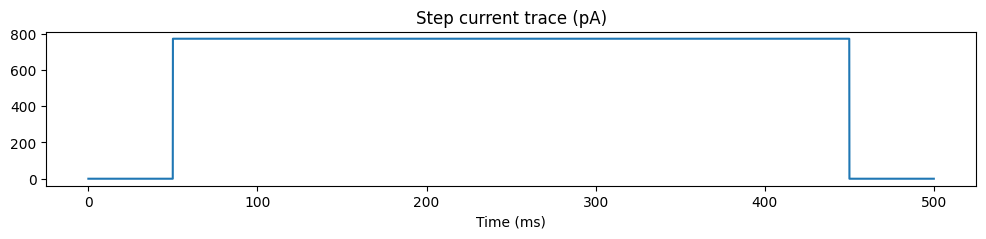

In [23]:
# Create the same step current as a numpy array
n_steps = int(scenario.t_max_ms / scenario.dt_ms)
current_trace_pA = np.zeros(n_steps)
stim_start_idx = int(scenario.stim_delay_ms / scenario.dt_ms)
stim_end_idx = int((scenario.stim_delay_ms + scenario.stim_duration_ms) / scenario.dt_ms)
current_trace_pA[stim_start_idx:stim_end_idx] = scenario.stim_current_pA

print(f"Current trace shape: {current_trace_pA.shape}")
print(f"Stim window: indices {stim_start_idx} to {stim_end_idx}")
print(f"Stim amplitude: {current_trace_pA[stim_start_idx]} pA")

plt.figure(figsize=(12, 2))
plt.plot(np.arange(n_steps) * scenario.dt_ms, current_trace_pA)
plt.title('Step current trace (pA)')
plt.xlabel('Time (ms)')
plt.show()

In [24]:
# Use the notebook's setup function
cell_nb, data_stimuli_nb, t_max_nb, trainable_params_nb = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=jnp.array(current_trace_pA),
    dt_ms=scenario.dt_ms,
    config=config_benchmark,
    trainable_params=scenario.trainable_params,
)

print(f"t_max_nb = {t_max_nb}")
print(f"data_stimuli_nb type = {type(data_stimuli_nb)}")
print(f"data_stimuli_nb is None? {data_stimuli_nb is None}")
print(f"trainable_params_nb = {trainable_params_nb}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
t_max_nb = 500.0
data_stimuli_nb type = <class 'tuple'>
data_stimuli_nb is None? False
trainable_params_nb = [{'capacitance': Array([191.66512], dtype=float32)}, {'AdEx_g_L': Array([9.589013], dtype=float32)}, {'AdEx_E_L': Array([-86.610664], dtype=float32)}, {'AdEx_v_T': Array([-56.55828], dtype=float32)}, {'AdEx_delta_T':

In [25]:
loss_fn_nb = make_guarino_loss_fn(cell=cell_nb, data_stimuli=data_stimuli_nb, t_max=t_max_nb, dt_ms=dt_ms, exp_features=exp_features_bench, stim_duration_ms=stim_duration_ms, stim_end_index=stim_end_index, loss_config=GuarinoLossConfig())

# Test: evaluate loss at initial params
loss_init_nb = loss_fn_nb(trainable_params_nb)
print(f"Initial loss (notebook path): {loss_init_nb}")

# Test: evaluate loss + gradient
loss_val_nb, grads_nb = jax.value_and_grad(loss_fn_nb)(trainable_params_nb)
print(f"Loss: {loss_val_nb}")
print("Gradients:")
for d in grads_nb:
    for name, g in d.items():
        print(f"  {name}: {g}")

Initial loss (notebook path): 0.8493270874023438
Loss: 0.8493270874023438
Gradients:
  capacitance: [-0.9433411]
  AdEx_g_L: [-4.8148293]
  AdEx_E_L: [4.4048495]
  AdEx_v_T: [-7.9603767]
  AdEx_delta_T: [-12.412251]
  AdEx_v_reset: [3.5937045]


## 6. Compare: are the two paths equivalent?

In [26]:
print("=" * 60)
print("COMPARISON: Benchmark vs Notebook path")
print("=" * 60)
print(f"\nt_max:     bench={t_max_bench}  nb={t_max_nb}  match={t_max_bench == t_max_nb}")
print(f"Loss:      bench={float(loss_init_bench):.6f}  nb={float(loss_init_nb):.6f}")
print(f"Loss diff: {abs(float(loss_init_bench) - float(loss_init_nb)):.2e}")

print("\nGradient comparison:")
for d_b, d_n in zip(grads, grads_nb):
    for (name_b, g_b), (name_n, g_n) in zip(d_b.items(), d_n.items()):
        diff = abs(float(g_b) - float(g_n))
        print(f"  {name_b:>25s}: bench={float(g_b):>12.4e}  nb={float(g_n):>12.4e}  diff={diff:.2e}")

print("\nParam comparison:")
for d_b, d_n in zip(trainable_params_bench, trainable_params_nb):
    for (name_b, v_b), (name_n, v_n) in zip(d_b.items(), d_n.items()):
        print(f"  {name_b:>25s}: bench={float(v_b.flatten()[0]):>10.4f}  nb={float(v_n.flatten()[0]):>10.4f}")

COMPARISON: Benchmark vs Notebook path

t_max:     bench=500.0  nb=500.0  match=True
Loss:      bench=0.849327  nb=0.849327
Loss diff: 0.00e+00

Gradient comparison:


TypeError: Only scalar arrays can be converted to Python scalars; got arr.ndim=1

## 7. Simulate both cells and compare voltage traces

This checks whether `cell.stimulate()` vs `cell.data_stimulate()` produce the same forward pass.

In [ ]:
# Forward pass through benchmark cell
results_bench = jx.integrate(
    cell_bench, params=trainable_params_bench, data_stimuli=None,
    delta_t=dt_ms, t_max=t_max_bench
)
v_bench = np.array(results_bench[0]).flatten()
s_bench = np.array(results_bench[2]).flatten()

# Forward pass through notebook cell
results_nb = jx.integrate(
    cell_nb, params=trainable_params_nb, data_stimuli=data_stimuli_nb,
    delta_t=dt_ms, t_max=t_max_nb
)
v_nb = np.array(results_nb[0]).flatten()
s_nb = np.array(results_nb[2]).flatten()

min_len = min(len(v_bench), len(v_nb))
v_diff = np.abs(v_bench[:min_len] - v_nb[:min_len])

print(f"Voltage shapes: bench={v_bench.shape}, nb={v_nb.shape}")
print(f"Max voltage difference: {v_diff.max():.6e}")
print(f"Mean voltage difference: {v_diff.mean():.6e}")
print(f"Bench spikes: {np.sum(s_bench > 0.5)}, NB spikes: {np.sum(s_nb > 0.5)}")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
t_plot = np.arange(min_len) * dt_ms

axes[0].plot(t_plot, v_bench[:min_len], label='Benchmark (cell.stimulate)', alpha=0.8)
axes[0].plot(t_plot, v_nb[:min_len], label='Notebook (data_stimulate)', alpha=0.8, ls='--')
axes[0].set_ylabel('Voltage (mV)')
axes[0].legend()
axes[0].set_title('Forward pass comparison at initial params')

axes[1].plot(t_plot, v_diff)
axes[1].set_ylabel('|V_bench - V_nb| (mV)')
axes[1].set_title('Voltage difference')

axes[2].plot(t_plot, s_bench[:min_len], label='bench spikes', alpha=0.8)
axes[2].plot(t_plot, s_nb[:min_len], label='nb spikes', alpha=0.8, ls='--')
axes[2].set_ylabel('Spike trace')
axes[2].set_xlabel('Time (ms)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Run training on BOTH paths and compare

In [ ]:
print("=" * 60)
print("TRAINING: Benchmark path (cell.stimulate, data_stimuli=None)")
print("=" * 60)

result_bench = train(
    loss_fn=loss_fn_bench,
    trainable_params=trainable_params_bench,
    config=config_benchmark,
    initial_params=initial_params,
)

In [ ]:
print("=" * 60)
print("TRAINING: Notebook path (data_stimulate, data_stimuli=tuple)")
print("=" * 60)

result_nb = train(
    loss_fn=loss_fn_nb,
    trainable_params=trainable_params_nb,
    config=config_benchmark,
    initial_params=initial_params,
)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(result_bench.loss_history, label='Benchmark path', marker='o', ms=3)
axes[0].plot(result_nb.loss_history, label='Notebook path', marker='s', ms=3)
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].set_title('Training comparison')
axes[0].grid(True, alpha=0.3)

axes[1].plot(result_bench.grad_norms, label='Benchmark path', marker='o', ms=3)
axes[1].plot(result_nb.grad_norms, label='Notebook path', marker='s', ms=3)
axes[1].set_ylabel('Gradient norm')
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBenchmark: final_loss={result_bench.final_loss:.6f}, best_loss={result_bench.best_loss:.6f} (epoch {result_bench.best_epoch})")
print(f"Notebook:  final_loss={result_nb.final_loss:.6f}, best_loss={result_nb.best_loss:.6f} (epoch {result_nb.best_epoch})")

## 9. Compare final parameters

In [ ]:
params_bench = result_bench.get_params_dict()
params_nb = result_nb.get_params_dict()

print(f"{'Param':>15s} | {'GT':>10s} | {'Init':>10s} | {'Bench':>10s} | {'NB':>10s} | {'Bench err%':>10s} | {'NB err%':>10s}")
print("-" * 90)
for p in scenario.trainable_params:
    gt_val = ground_truth_params[p]
    init_val = initial_params[p]
    bench_val = params_bench.get(p, float('nan'))
    nb_val = params_nb.get(p, float('nan'))
    bench_err = abs(bench_val - gt_val) / abs(gt_val) * 100 if gt_val != 0 else 0
    nb_err = abs(nb_val - gt_val) / abs(gt_val) * 100 if gt_val != 0 else 0
    print(f"{p:>15s} | {gt_val:>10.3f} | {init_val:>10.3f} | {bench_val:>10.3f} | {nb_val:>10.3f} | {bench_err:>9.2f}% | {nb_err:>9.2f}%")

## 10. Loss floor check

Evaluate loss at ground truth params to see if the target is even achievable.

In [ ]:
# Create a cell with ground truth params using the benchmark path
cell_gt, _, t_max_gt, params_gt = setup_trainable_cell_step(
    initial_params=ground_truth_params,
    stim_current_pA=scenario.stim_current_pA,
    stim_duration_ms=scenario.stim_duration_ms,
    stim_delay_ms=scenario.stim_delay_ms,
    dt_ms=scenario.dt_ms,
    config=config_benchmark,
    trainable_params=scenario.trainable_params,
)

loss_fn_gt = make_guarino_loss_fn(cell=cell_gt, data_stimuli=None, t_max=t_max_gt, dt_ms=dt_ms, exp_features=exp_features_bench, stim_duration_ms=stim_duration_ms, stim_end_index=stim_end_index, loss_config=GuarinoLossConfig())

loss_floor = loss_fn_gt(params_gt)
print(f"Loss floor (GT params, benchmark path): {float(loss_floor):.6f}")
print(f"If this is high, the target is unreachable via the benchmark setup!")

# Also check gradients at GT
loss_gt, grads_gt = jax.value_and_grad(loss_fn_gt)(params_gt)
print(f"\nGradients at ground truth:")
for d in grads_gt:
    for name, g in d.items():
        print(f"  {name}: {float(g):.6e}")